Best params {'svr__C': 5000, 'svr__epsilon': 250, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}
R2: 0.8981040352759218
MAE: 14965.231833325699
RMSE: 21893.26864544463


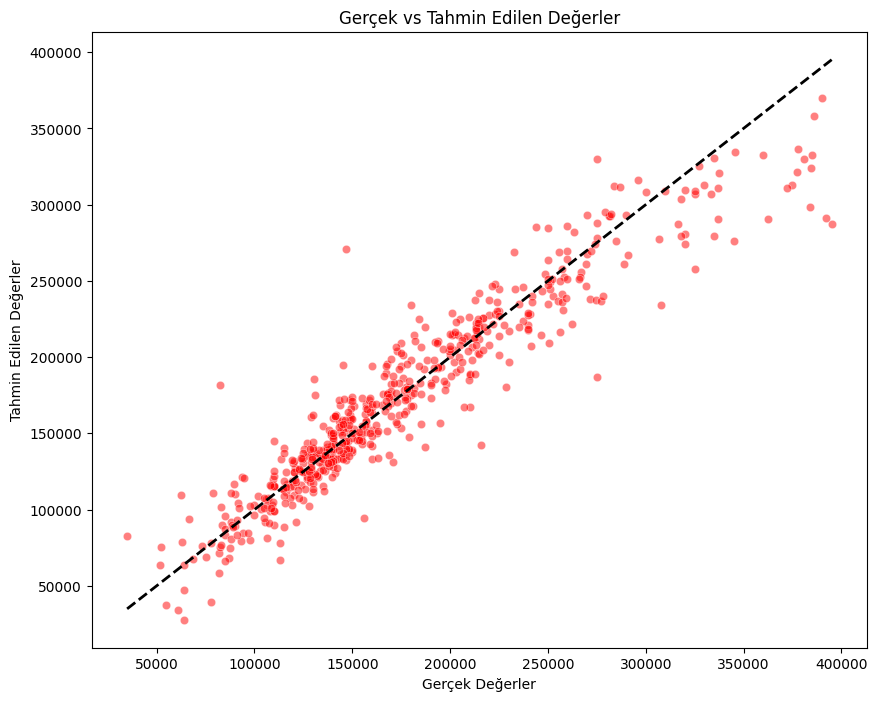

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Ames_Housing_Processed.csv")


X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

steps = [
    ('scaler', StandardScaler()),
    ('svr', SVR())
]

pipeline = Pipeline(steps)

param_grid = {
    'svr__C': [4000, 5000, 6000],
    'svr__epsilon': [100, 150, 200, 250],
    'svr__gamma': ['scale', 'auto', 0.001, 0.01],
    'svr__kernel': ['rbf', 'linear']
}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Best params", grid_search.best_params_)

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', lw=2, linestyle='--')
plt.xlabel("Actual Sale Prices ($)")
plt.ylabel("Predicted Sale Prices ($)")
plt.title("Actual vs. Predicted Housing Prices (Stacking Ensemble)")
plt.show()
